# Titanic Survival Prediction

## 1. Problem Definition

Predict whether a passenger survived the Titanic disaster based on passenger attributes. 

## 2. Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/Titanic_train.csv")

## 3. Exploratory Data Analysis

#Let's start with EDA

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Rows: 891 passengers

Columns: 12 features

Mixed data types: 
- Numerical: Age, Fare,
- Categorical: Sex, Embarked, 
- Text: Name, Ticket

Missing values: 
- Age: 177 out of 891
- Cabin: 687 out of 891 
- Embarked: 2 out of 891

Interpretation:

Cabin: mostly useless (approx. 77% missing)

    --> drop it
    - extract patterns (later)

Age: important but incomplete

    - very relevant feature
    - missing values must be handled
        --> fill with median (simple + robust)

Embarked: almost complete

    - only 2 missing
    --> fill with most common value (mode)

Important questions:

1. Does gender affect survival?
2. Does class affect survival?
3. Does age affect survival?

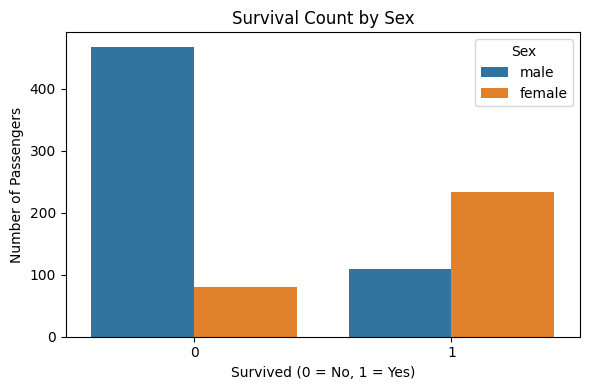

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", hue="Sex", data=df)

plt.title("Survival Count by Sex")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.tight_layout()

plt.savefig("../reports/survival_by_sex.png")

plt.show()

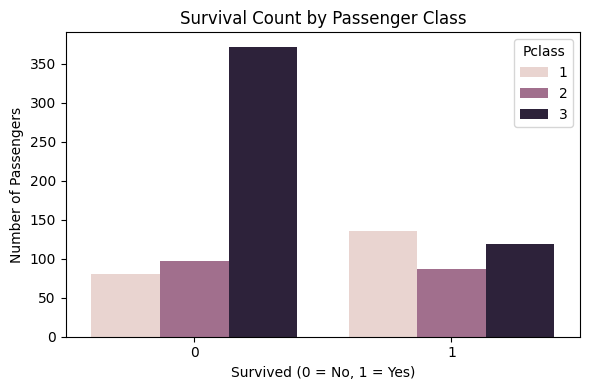

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", hue="Pclass", data=df)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.legend(title="Pclass")

plt.tight_layout()

plt.savefig("../reports/survival_by_pclass.png")

plt.show()

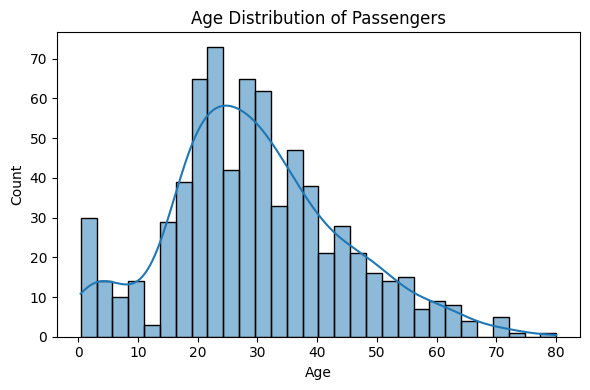

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(df["Age"].dropna(), bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/age_distribution.png")

plt.show()

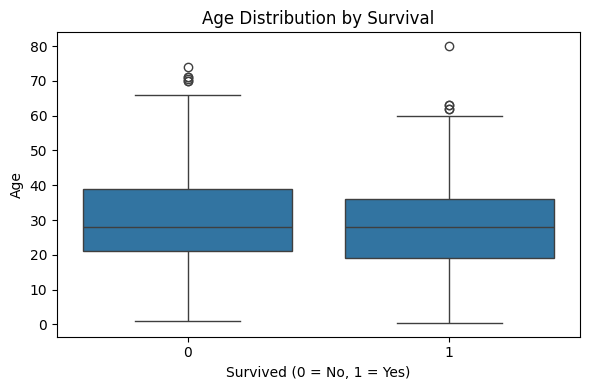

In [10]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.tight_layout()

plt.savefig("../reports/age_by_survival_boxplot.png")

plt.show()

Age is a weak feature on its own because the distributions overlap heavily

In [11]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

It implies that:
- Gender is a very strong predictive feature
- Likely reflects “women and children first” evacuation behavior

In [12]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

It implies that:
- Socioeconomic status strongly affected survival
- Access/location on ship likely mattered

In [13]:
df.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

This only tells us central tendency.
It does not tell us:
- distribution shape
- overlap
- variance